In [81]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [82]:
df = pd.read_csv("../../../PreviousDataset.csv")

In [ ]:
numeric_cols = ['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees',
                'Latitude_Degrees', 'Windspeed',
                'TSA', 'TSA_DHW', 'SSTA_DHW', 'SSTA_Minimum']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filter
df = df[df['SSTA'] > 0]
df = df[df['Year'] >= 2003]

In [84]:
drop_cols = ['City_Town', 'City_Town_2', 'City_Town_3', 'Ocean', 'Realm', 'Ecoregion', 'ID', 'Country_Name', 'State_Island_Province', 'Date2', 'SSTA_Mean']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Month encoding
df['Month'] = df['Date'].dt.month
df = df.dropna(subset=['Average_Bleaching'])

In [ ]:
month_dummies = pd.get_dummies(df['Month'], prefix='Month', drop_first=False)
df = pd.concat([df, month_dummies], axis=1)
df = df.drop(columns=['Month', 'Date'])

In [86]:
df.shape

(6112, 48)

# PCA

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [88]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [89]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [90]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'ClimSST', 'SSTA']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [91]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [92]:
pca = PCA(n_components=0.75)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

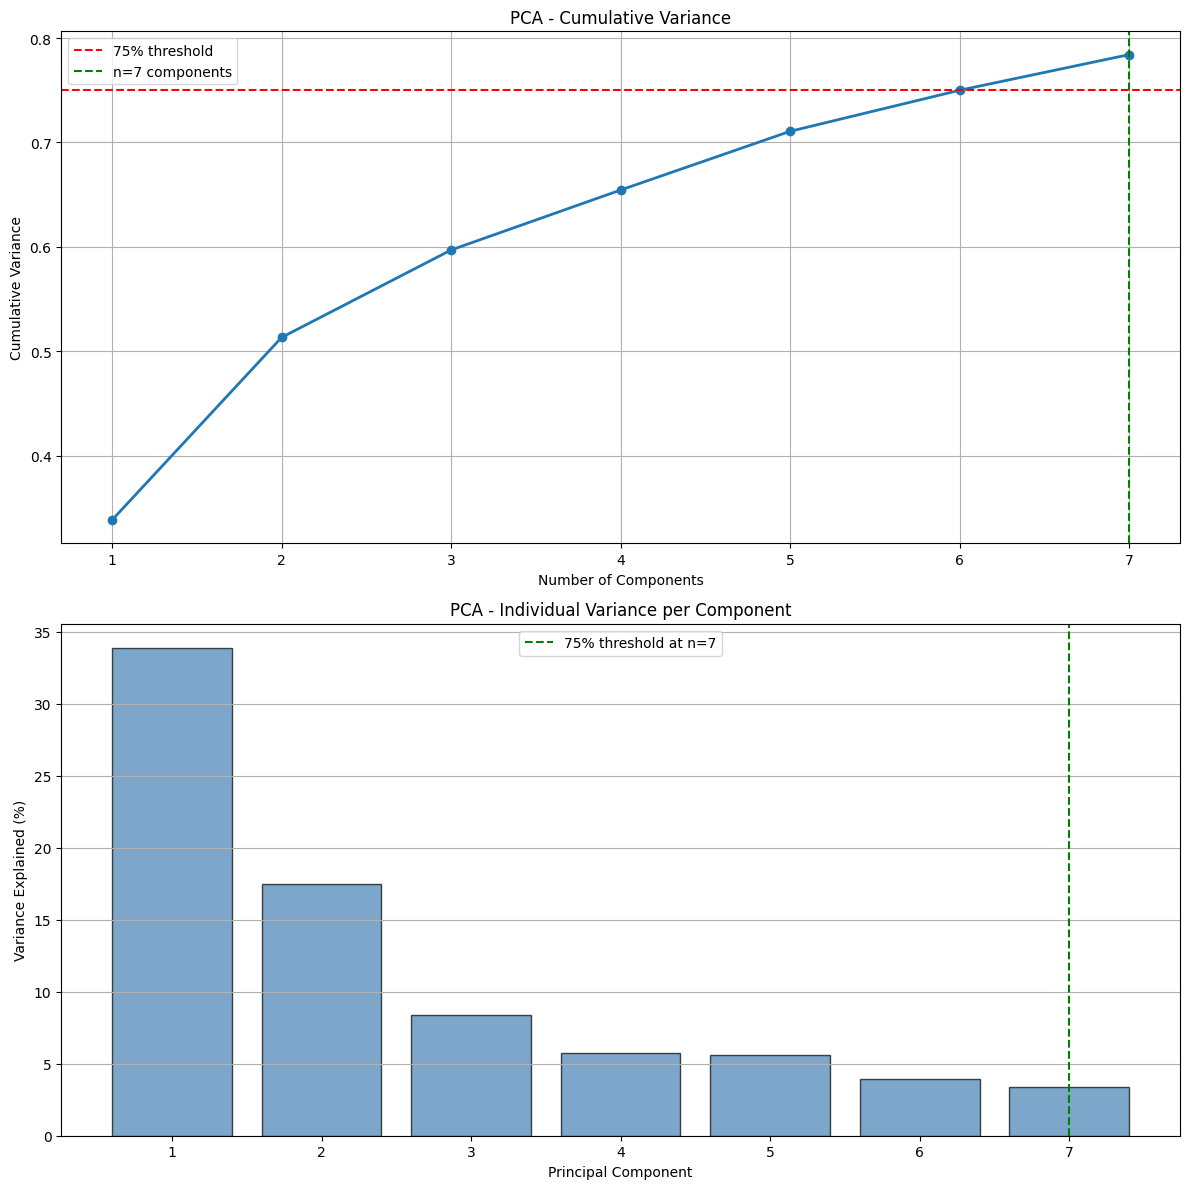

✅ Components needed for 75% variance: 7
✅ Variance explained by 7 components: 0.7841


In [93]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [94]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_df,  X_test_raw_month,  X_test_fe],       axis=1)

# lazyPredict

In [31]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [32]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared     R-Squared         RMSE  \
Model                                                                          
HistGradientBoostingRegressor            0.389674      0.421638     7.366422   
RandomForestRegressor                    0.331953      0.366941     7.706885   
ExtraTreesRegressor                      0.326959      0.362208     7.735640   
BaggingRegressor                         0.287847      0.325144     7.957236   
XGBRegressor                             0.282415      0.319997     7.987525   
GradientBoostingRegressor                0.230984      0.271260     8.268812   
MLPRegressor                             0.228491      0.268898     8.282205   
KNeighborsRegressor                      0.205596      0.247201     8.404196   
Lars                                     0.047991      0.097851     9.200172   
TransformedTargetRegressor               0.040088      0.090362     9.238282   
LinearRegression                        

In [33]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor

# OpTuna

In [34]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12',
              'Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'ClimSST', 'SSTA']

X_train_no_month = X_train_raw.copy() 
X_train_month = pd.concat([
    X_train_raw_month.reset_index(drop=True),
    X_train_raw_fe.reset_index(drop=True)
], axis=1)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [35]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-06 14:30:09,886] A new study created in memory with name: no-name-f43b8d95-12a4-44c0-8725-cbf0e4c537d3
[I 2026-05-06 14:30:10,921] Trial 0 finished with value: 0.29011956284979545 and parameters: {'n_estimators': 287, 'max_depth': 30, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.29011956284979545.
[I 2026-05-06 14:30:11,641] Trial 1 finished with value: 0.2905189935474401 and parameters: {'n_estimators': 196, 'max_depth': 38, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.2905189935474401.
[I 2026-05-06 14:30:12,347] Trial 2 finished with value: 0.20433850239435883 and parameters: {'n_estimators': 189, 'max_depth': 32, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.2905189935474401.
[I 2026-05-06 14:30:12,994] Trial 3 finished with value: 0.2046237946765431 and parameters: {'n_estimators': 196, 'max_depth': 40, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with va

========== ET BEST ==========
{'n_estimators': 129, 'max_depth': 35, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.3221


In [36]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-06 14:30:41,703] A new study created in memory with name: no-name-f2702af6-22ad-41f4-91c6-c2175c9e4dba
[I 2026-05-06 14:30:42,415] Trial 0 finished with value: 0.259812233250507 and parameters: {'n_estimators': 96, 'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.259812233250507.
[I 2026-05-06 14:30:43,728] Trial 1 finished with value: 0.2735827723660212 and parameters: {'n_estimators': 265, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.2735827723660212.
[I 2026-05-06 14:30:45,241] Trial 2 finished with value: 0.30251035056571596 and parameters: {'n_estimators': 268, 'max_depth': 32, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.30251035056571596.
[I 2026-05-06 14:30:45,918] Trial 3 finished with value: 0.20166342276119933 and parameters: {'n_estimators': 127, 'max_depth': 7, 'mi

========== RF BEST ==========
{'n_estimators': 217, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.3206


In [37]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-06 14:31:35,088] A new study created in memory with name: no-name-f9cc4ee9-1abd-4c27-b2a6-ab733a107b51
[I 2026-05-06 14:31:36,933] Trial 0 finished with value: 0.2813406372767333 and parameters: {'max_iter': 337, 'max_depth': 9, 'learning_rate': 0.0477051840730052, 'min_samples_leaf': 37, 'l2_regularization': 0.21176712909733897}. Best is trial 0 with value: 0.2813406372767333.
[I 2026-05-06 14:31:37,357] Trial 1 finished with value: 0.12752600656523053 and parameters: {'max_iter': 114, 'max_depth': 4, 'learning_rate': 0.012488975603412781, 'min_samples_leaf': 42, 'l2_regularization': 0.789898418934952}. Best is trial 0 with value: 0.2813406372767333.
[I 2026-05-06 14:31:37,828] Trial 2 finished with value: 0.12866795100301298 and parameters: {'max_iter': 55, 'max_depth': 7, 'learning_rate': 0.012131958865505218, 'min_samples_leaf': 20, 'l2_regularization': 0.6978131145183921}. Best is trial 0 with value: 0.2813406372767333.
[I 2026-05-06 14:31:38,744] Trial 3 finished with 

========== HGB BEST ==========
{'max_iter': 220, 'max_depth': 11, 'learning_rate': 0.05447920893122586, 'min_samples_leaf': 13, 'l2_regularization': 0.25737717069849064}
Best R²: 0.3112


# Start

In [95]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=220,
    max_depth=11,
    learning_rate=0.0545,
    min_samples_leaf=13,
    l2_regularization=0.257,
    random_state=42
)
# {'max_iter': 220, 'max_depth': 11, 'learning_rate': 0.05447920893122586, 'min_samples_leaf': 13, 'l2_regularization': 0.25737717069849064}


et_model = ExtraTreesRegressor(
    n_estimators=129,
    max_depth=35,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 129, 'max_depth': 35, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

rf_model = RandomForestRegressor(
    n_estimators=217, 
    max_depth=19, 
    min_samples_split =  3,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)
# {'n_estimators': 217, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}



In [96]:
from sklearn.metrics import mean_absolute_error

In [97]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('rf',  rf_model)
])

# Train all
hgb_model.fit(X_train_pca, y_train)
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
voting.fit(X_train_pca, y_train)

models = {
    'HistGradientBoost': hgb_model,
    'ExtraTrees':        et_model,
    'RandomForest':      rf_model,
    'Voting (Ensemble)': voting
}

print("=" * 65)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 65)
print(f"{'Model':<22}{'R²':>10}{'RMSE':>12}{'MAE':>10}{'Acc%':>10}")
print("-" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<22}{r2:>10.4f}{rmse:>12.4f}{mae:>10.4f}{100-mae:>10.2f}")
print("-" * 65)
print(f"{'Paper baseline:':<22}{0.25:>10.4f}{7.91:>12.4f}{'—':>10}{96:>10.2f}")
print("=" * 65)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
HistGradientBoost         0.3188      7.6599    3.2579     96.74
ExtraTrees                0.3301      7.5959    3.0329     96.97
RandomForest              0.3502      7.4811    3.2265     96.77
Voting (Ensemble)         0.3628      7.4084    3.0918     96.91
-----------------------------------------------------------------
Paper baseline:           0.2500      7.9100         —     96.00


# K-Fold

In [98]:
from sklearn.model_selection import KFold
from sklearn.base import clone

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Categorical/extra columns (จะ append ทีหลัง — ไม่ผ่าน PCA)
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']
paper_features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'ClimSST', 'SSTA']
extra_cols = month_cols + paper_features

# X_extra = month + paper (จะเพิ่มทีหลัง)
X_extra = X[extra_cols].copy()

# X_for_pca = ทุก features รวม paper features (จะผ่าน PCA)
# แต่ตัด month ออก (เพราะ month เป็น categorical ไม่ควรเข้า PCA)
X_for_pca = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGradientBoost':    hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_for_pca):
        # Split numeric (for PCA) and extra (month + paper) separately
        X_fold_train, X_fold_test = X_for_pca.iloc[train_idx], X_for_pca.iloc[test_idx]
        extra_fold_train = X_extra.iloc[train_idx].reset_index(drop=True)
        extra_fold_test  = X_extra.iloc[test_idx].reset_index(drop=True)
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only — รวม paper features)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.75)   # ← เปลี่ยนเป็น 0.75 ให้ตรง Optuna
        X_train_pca_fold = pca.fit_transform(X_train_ss)
        X_test_pca_fold  = pca.transform(X_test_ss)

        # Reattach extra columns (month + paper pure) after PCA
        n_pcs   = X_train_pca_fold.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([pd.DataFrame(X_train_pca_fold, columns=pc_cols), extra_fold_train], axis=1)
        X_test_final  = pd.concat([pd.DataFrame(X_test_pca_fold,  columns=pc_cols), extra_fold_test ], axis=1)

        # Train & evaluate
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.3905        7.4949        2.9969
RandomForest                  0.3753        7.5954        3.2463
HistGradientBoost             0.3770        7.5778        3.2876
Voting (Ensemble)             0.4090        7.3835        3.0951
